# Proyecto de series de tiempo.
### Mayor magnitud de sismos registrados cada dia de 2024 a 2025 en México.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [7]:
sismosdf = pd.read_csv('SSNMX_catalogo_20240101_20251231.csv', skiprows=4)
sismosdf.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2024-01-01,00:15:51,3.2,18.7483,-104.6020,16.5,"45 km al SUROESTE de MANZANILLO, COL",2024-01-01,06:15:51,revisado
1,2024-01-01,00:30:39,4.3,15.5482,-95.8245,16.1,"41 km al SURESTE de CRUCECITA, OAX",2024-01-01,06:30:39,revisado
2,2024-01-01,00:53:59,3.1,19.5943,-102.4950,5.3,"2 km al OESTE de LOS REYES DE SALGADO, MICH",2024-01-01,06:53:59,revisado
3,2024-01-01,01:09:24,3.2,18.4185,-100.4230,55.4,"19 km al NOROESTE de ARCELIA, GRO",2024-01-01,07:09:24,revisado
4,2024-01-01,01:16:57,3.1,19.7267,-104.6570,54.0,"27 km al NOROESTE de CASIMIRO CASTILLO, JAL",2024-01-01,07:16:57,revisado


In [8]:
sismosdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72323 entries, 0 to 72322
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       72323 non-null  object 
 1   Hora                        72316 non-null  object 
 2   Magnitud                    72316 non-null  float64
 3   Latitud                     72316 non-null  float64
 4   Longitud                    72316 non-null  float64
 5   Profundidad                 72316 non-null  float64
 6   Referencia de localizacion  72316 non-null  object 
 7   Fecha UTC                   72316 non-null  object 
 8   Hora UTC                    72316 non-null  object 
 9   Estatus                     72316 non-null  object 
dtypes: float64(4), object(6)
memory usage: 5.5+ MB


# Variable objetivo y unidades
Variable objetivo: Magnitud.
Unidades: La magnitud de un sismo es adimensional. Se calcula mediante fórmulas matemáticas distintas.
Magnitud coda (Mc): Sismos menores de 4.5
Magnitud de momento (Mw): Sismos mayores de 4.5
Magnitud de energía (ME): Sismos mayores de 4.5 con epicentro en Guerrero.
Magnitud de amplitud (MA): Sismos en México.

In [9]:
sismosdf['Fecha'] = pd.to_datetime(sismosdf['Fecha'], errors='coerce')
sismosdf = sismosdf.dropna(subset=['Fecha'])
idx_maximos = sismosdf.groupby('Fecha')['Magnitud'].idxmax()
sismos_max_diarios = sismosdf.loc[idx_maximos]
sismos_max_diarios.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
1,2024-01-01,00:30:39,4.3,15.5482,-95.8245,16.1,"41 km al SURESTE de CRUCECITA, OAX",2024-01-01,06:30:39,revisado
69,2024-01-02,00:26:11,4.4,15.6295,-94.9672,26.8,"66 km al SURESTE de SALINA CRUZ, OAX",2024-01-02,06:26:11,revisado
247,2024-01-03,21:43:28,4.6,15.3383,-92.8212,105.3,"14 km al SURESTE de MAPASTEPEC, CHIS",2024-01-04,03:43:28,revisado
318,2024-01-04,19:29:58,4.2,15.6807,-97.3685,6.2,"37 km al SUR de RIO GRANDE, OAX",2024-01-05,01:29:58,revisado
386,2024-01-05,17:20:08,4.2,14.4513,-92.8245,24.0,"77 km al SUROESTE de CD HIDALGO, CHIS",2024-01-05,23:20:08,revisado


#Formato y rango de tiempo
Formato: Originalmente, se tienen datos diarios en distintos momentos. Sin embargo, se limpió el conjunto de datos para que el formato sea cada día, pero, no se cumple necesariamente un periodo de 24 horas.
Lo que si es un hecho, es que la fecha y hora estan en el tiempo del Centro de México.
Rango de tiempo: Desde 01/01/2024 hasta 31/12/2025

In [10]:
sismos_max_diarios.shape

(731, 10)

# Cantidad de puntos
Una vez limpiado el conjunto de datos para obtener únicamente el sismo con mayor magnitud registrado al día desde 2024 hasta 2025, se tiene un total de 731 puntos, esto debido a que 2024 fue año bisiesto.

In [11]:
sismosdf.isnull().sum()

Fecha                         0
Hora                          0
Magnitud                      0
Latitud                       0
Longitud                      0
Profundidad                   0
Referencia de localizacion    0
Fecha UTC                     0
Hora UTC                      0
Estatus                       0
dtype: int64

In [12]:
sismos_max_diarios.isnull().sum()

Fecha                         0
Hora                          0
Magnitud                      0
Latitud                       0
Longitud                      0
Profundidad                   0
Referencia de localizacion    0
Fecha UTC                     0
Hora UTC                      0
Estatus                       0
dtype: int64

# Valores nulos
No se cuenta con ningún valor nulo en el conjunto de datos original y limpio.

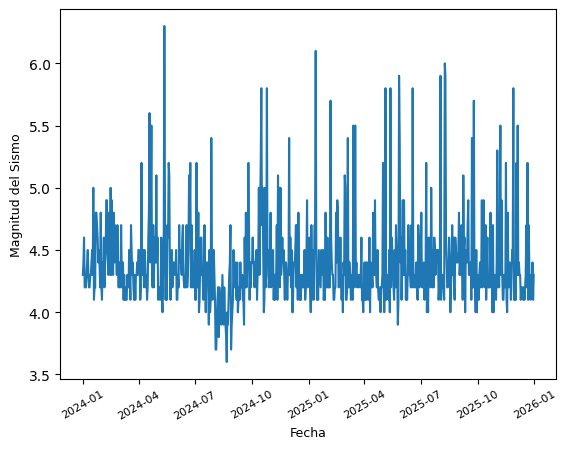

In [13]:
plt.plot(sismos_max_diarios['Fecha'], sismos_max_diarios['Magnitud'])
plt.xlabel('Fecha', fontsize=9)
plt.ylabel('Magnitud del Sismo', fontsize=9)
plt.xticks(rotation=30, fontsize=8)
plt.show()

# Exploración

In [14]:
sismos_max_diarios['Mes'] = pd.to_datetime(sismos_max_diarios['Fecha']).dt.month
sismos_max_diarios.groupby('Mes')['Magnitud'].describe()

,count,mean,std,min,25%,50%,75%,max
Mes,,,,,,,,
1,62.0,4.400000,0.314147,4.0,4.200,4.3,4.500,6.1
2,57.0,4.454386,0.310570,4.0,4.200,4.4,4.600,5.7
3,62.0,4.333871,0.309915,4.0,4.200,4.3,4.375,5.5
4,60.0,4.403333,0.328307,4.0,4.200,4.3,4.500,5.6
5,62.0,4.467742,0.498448,3.9,4.200,4.3,4.600,6.3
6,60.0,4.421667,0.308683,4.1,4.200,4.3,4.525,5.8
7,62.0,4.372581,0.300911,3.9,4.200,4.3,4.500,5.4
8,62.0,4.264516,0.455961,3.6,4.025,4.2,4.400,6.0
9,60.0,4.393333,0.342902,3.9,4.200,4.3,4.500,5.7


In [15]:
sismos_max_diarios['Magnitud'].max() #sismo con mayor magnitud registrado en el dataset

np.float64(6.3)

In [16]:
sismos_max_diarios['Año'] = pd.to_datetime(sismos_max_diarios['Fecha']).dt.year

In [17]:
varianza_anual = (sismos_max_diarios.groupby('Año')['Magnitud'].var())
varianza_anual

Año
2024    0.110688
2025    0.148572
Name: Magnitud, dtype: float64

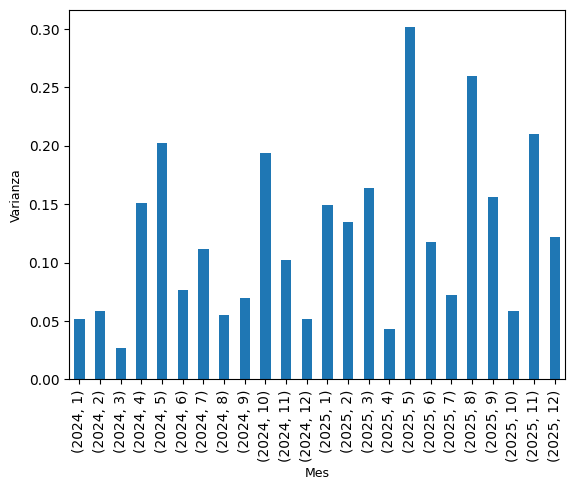

In [18]:
varianza_mes_anio = (sismos_max_diarios.groupby(['Año', 'Mes'])['Magnitud'].var())

varianza_mes_anio.plot(kind='bar')
plt.xlabel('Mes', fontsize=9)
plt.ylabel('Varianza', fontsize=9)
plt.show()

# Análisis estadístico

In [19]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# 4. Estadísticas descriptivas de la variable objetivo (Magnitud)

# Estadísticas generales de magnitud
print("Estadísticas descriptivas de Magnitud:")
print(sismos_max_diarios['Magnitud'].describe())

# Añadir columnas de mes y año
sismos_max_diarios['Mes'] = sismos_max_diarios['Fecha'].dt.month
sismos_max_diarios['Año'] = sismos_max_diarios['Fecha'].dt.year
sismos_max_diarios['Dia'] = sismos_max_diarios['Fecha'].dt.day
sismos_max_diarios['Dia_semana'] = sismos_max_diarios['Fecha'].dt.day_name()

Estadísticas descriptivas de Magnitud:
count    731.000000
mean       4.395486
std        0.360014
min        3.600000
25%        4.200000
50%        4.300000
75%        4.500000
max        6.300000
Name: Magnitud, dtype: float64


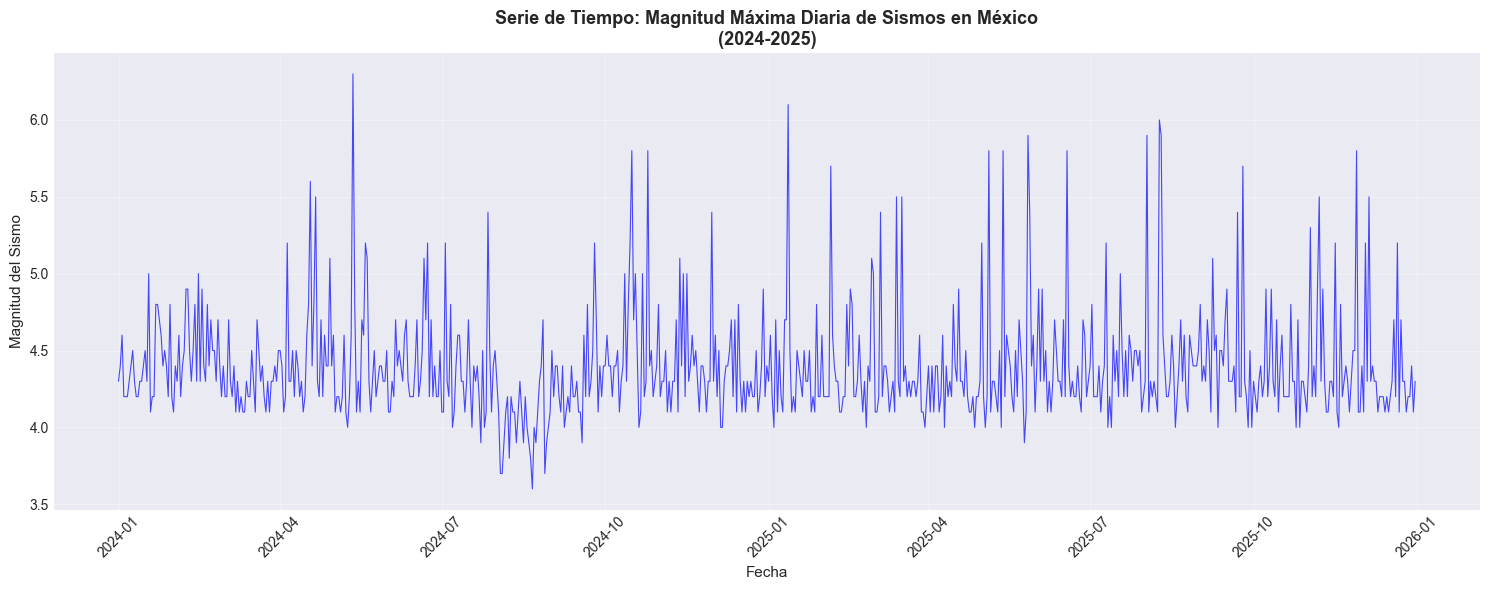

In [20]:
# 5. Visualización de la serie de tiempo original

# Gráfica de serie de tiempo original
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(sismos_max_diarios['Fecha'], sismos_max_diarios['Magnitud'],
        linewidth=0.8, alpha=0.7, color='blue')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud del Sismo', fontsize=11)
ax.set_title('Serie de Tiempo: Magnitud Máxima Diaria de Sismos en México\n(2024-2025)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


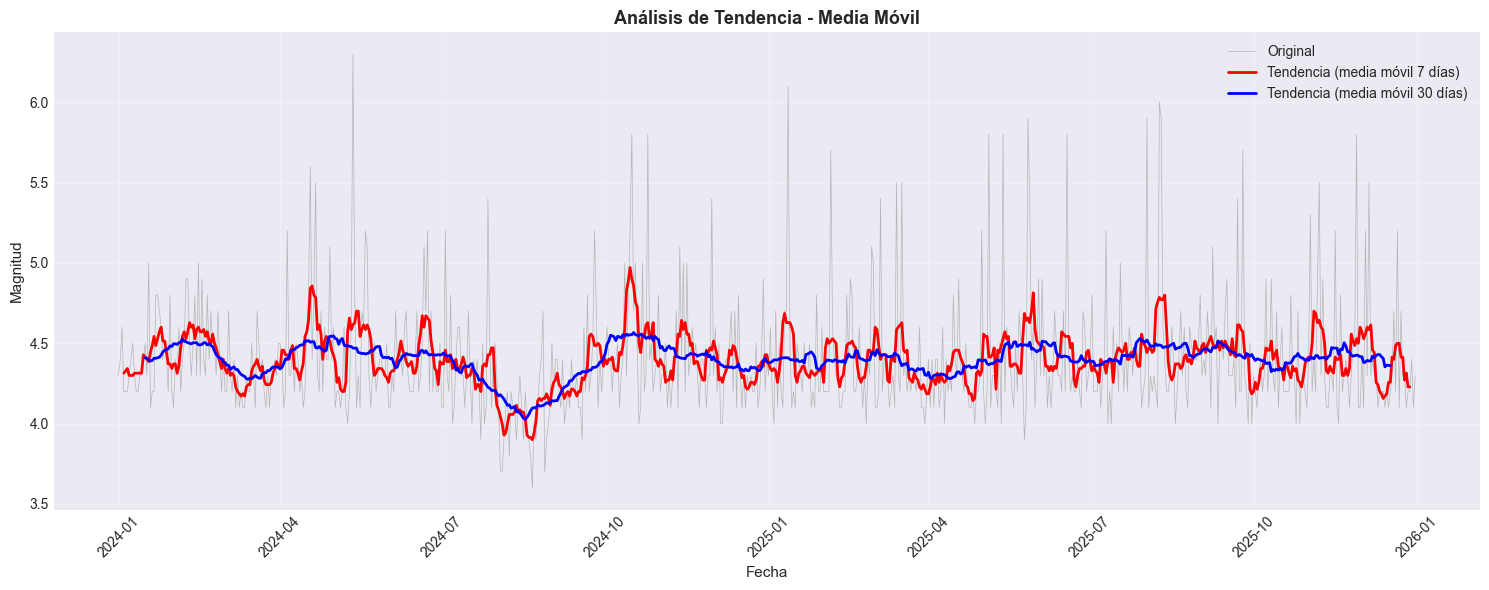

In [21]:
# 6. Análisis de tendencia

# Calcular tendencia usando media móvil
sismos_max_diarios['Tendencia_MA7'] = sismos_max_diarios['Magnitud'].rolling(window=7, center=True).mean()
sismos_max_diarios['Tendencia_MA30'] = sismos_max_diarios['Magnitud'].rolling(window=30, center=True).mean()

# Visualizar tendencia
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(sismos_max_diarios['Fecha'], sismos_max_diarios['Magnitud'],
        linewidth=0.5, alpha=0.5, color='gray', label='Original')
ax.plot(sismos_max_diarios['Fecha'], sismos_max_diarios['Tendencia_MA7'],
        linewidth=2, color='red', label='Tendencia (media móvil 7 días)')
ax.plot(sismos_max_diarios['Fecha'], sismos_max_diarios['Tendencia_MA30'],
        linewidth=2, color='blue', label='Tendencia (media móvil 30 días)')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud', fontsize=11)
ax.set_title('Análisis de Tendencia - Media Móvil', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

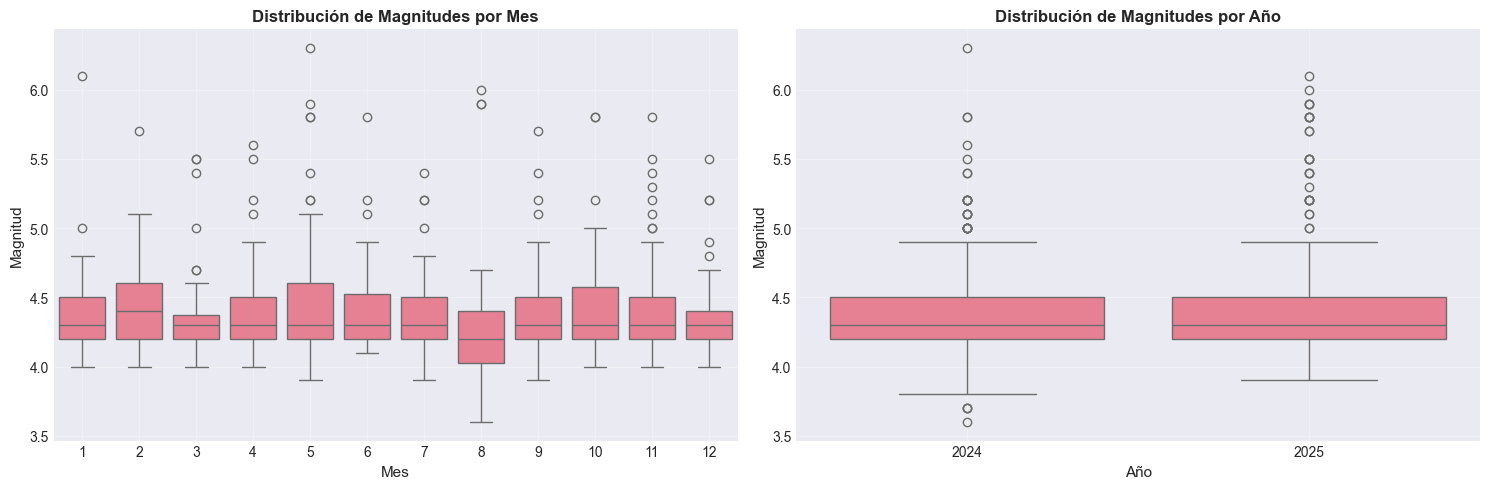

Estadísticas por mes:
      mean    std  min  max  count
Mes                               
1    4.400  0.314  4.0  6.1     62
2    4.454  0.311  4.0  5.7     57
3    4.334  0.310  4.0  5.5     62
4    4.403  0.328  4.0  5.6     60
5    4.468  0.498  3.9  6.3     62
6    4.422  0.309  4.1  5.8     60
7    4.373  0.301  3.9  5.4     62
8    4.265  0.456  3.6  6.0     62
9    4.393  0.343  3.9  5.7     60
10   4.447  0.371  4.0  5.8     62
11   4.447  0.393  4.0  5.8     60
12   4.348  0.292  4.0  5.5     62


In [22]:
#7. Análisis de estacionalidad

# Boxplot por mes para ver estacionalidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por mes (todos los datos)
sns.boxplot(data=sismos_max_diarios, x='Mes', y='Magnitud', ax=axes[0])
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Magnitud', fontsize=11)
axes[0].set_title('Distribución de Magnitudes por Mes', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Boxplot por año
sns.boxplot(data=sismos_max_diarios, x='Año', y='Magnitud', ax=axes[1])
axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Magnitud', fontsize=11)
axes[1].set_title('Distribución de Magnitudes por Año', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por mes
estadisticas_mes = sismos_max_diarios.groupby('Mes')['Magnitud'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Estadísticas por mes:")
print(estadisticas_mes.round(3))

# Análisis de los componentes

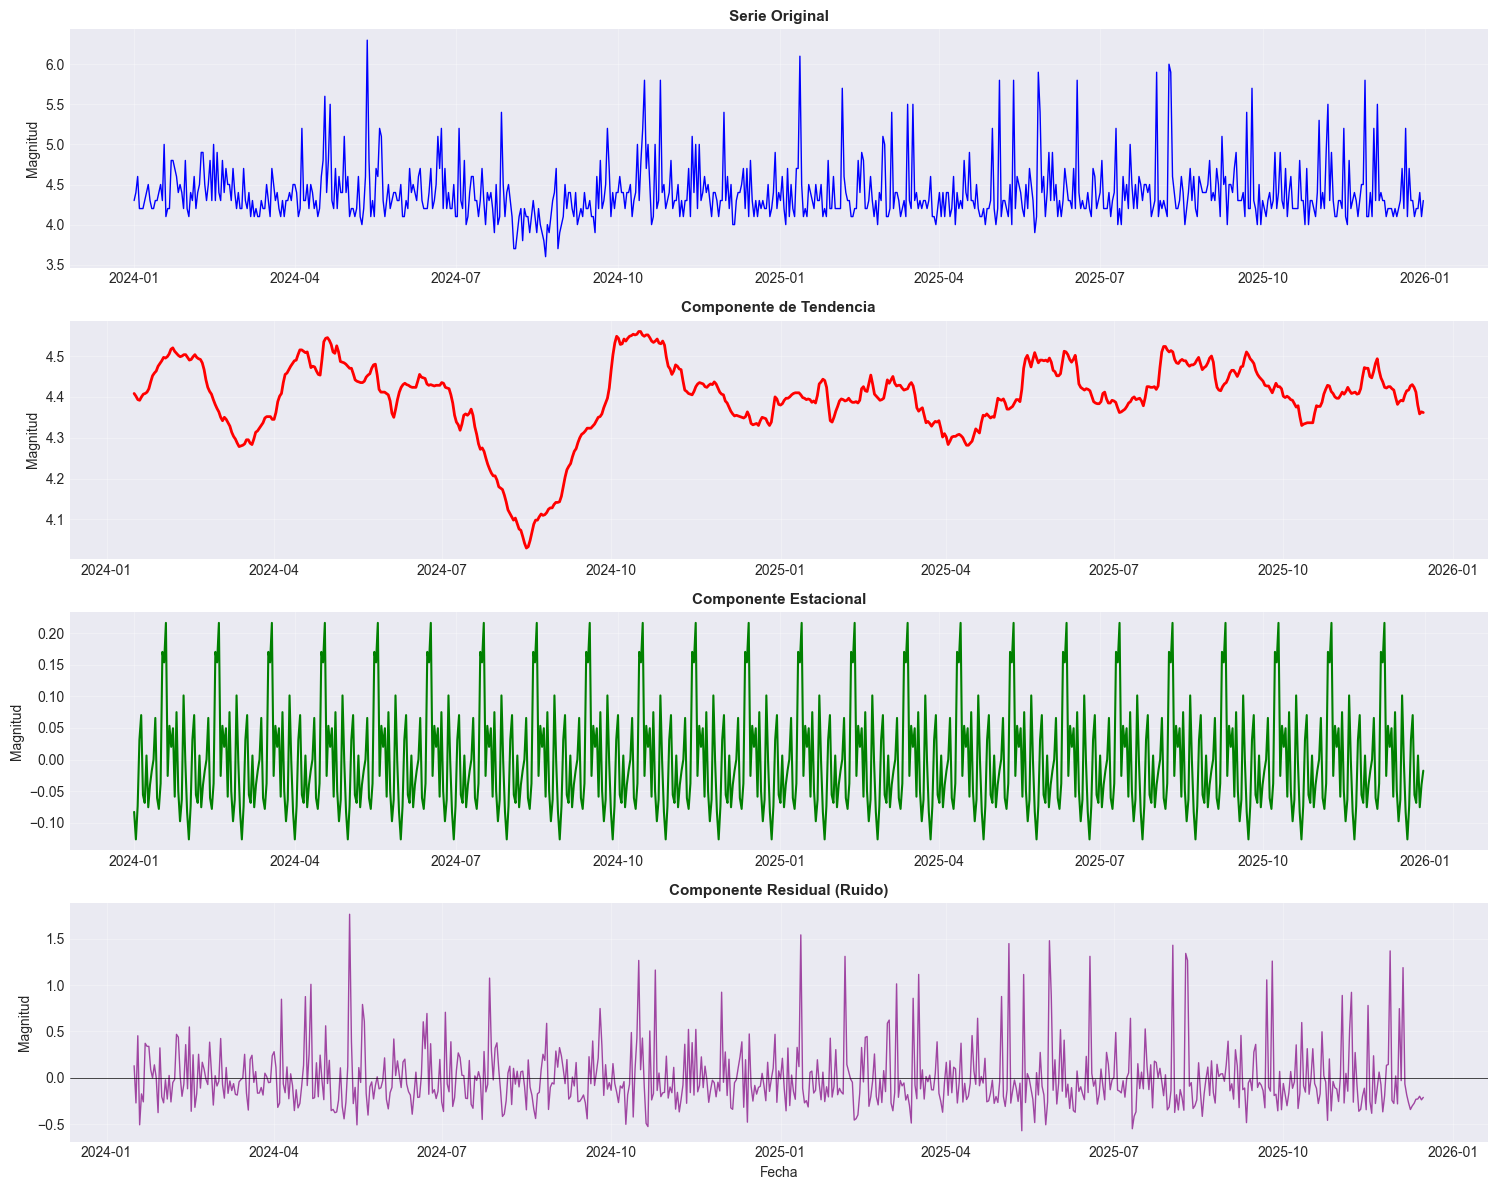

In [23]:
# 8. Descomposición de la serie de tiempo (Tendencia, Estacionalidad, Residuos)

# Preparar datos para descomposición (necesitamos serie con frecuencia diaria)
sismos_ts = sismos_max_diarios.set_index('Fecha')['Magnitud'].sort_index()

# Completamos fechas faltantes (si las hay)
fechas_completas = pd.date_range(start=sismos_ts.index.min(), end=sismos_ts.index.max(), freq='D')
sismos_ts = sismos_ts.reindex(fechas_completas)

# Interpolacion de valores faltantes (si existen)
if sismos_ts.isnull().any():
    sismos_ts = sismos_ts.interpolate(method='linear')
    print(f"Se interpolaron {sismos_ts.isnull().sum()} valores faltantes")

# Realizar descomposición (estacionalidad anual = 365 días)
descomposicion = seasonal_decompose(sismos_ts, model='additive', period=30)  # period=30 para estacionalidad mensual

# Visualizar descomposición
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))

# Original
ax1.plot(sismos_ts.index, sismos_ts, color='blue', linewidth=1)
ax1.set_title('Serie Original', fontsize=11, fontweight='bold')
ax1.set_ylabel('Magnitud')
ax1.grid(True, alpha=0.3)

# Tendencia
ax2.plot(descomposicion.trend.index, descomposicion.trend, color='red', linewidth=2)
ax2.set_title('Componente de Tendencia', fontsize=11, fontweight='bold')
ax2.set_ylabel('Magnitud')
ax2.grid(True, alpha=0.3)

# Estacionalidad
ax3.plot(descomposicion.seasonal.index, descomposicion.seasonal, color='green', linewidth=1.5)
ax3.set_title('Componente Estacional', fontsize=11, fontweight='bold')
ax3.set_ylabel('Magnitud')
ax3.grid(True, alpha=0.3)

# Residuos
ax4.plot(descomposicion.resid.index, descomposicion.resid, color='purple', linewidth=1, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_title('Componente Residual (Ruido)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Magnitud')
ax4.set_xlabel('Fecha')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# 9. Análisis estadístico de los componentes

# Estadísticas de los componentes
print("Estadísticas de los componentes de descomposición:")
print("\nComponente de Tendencia:")
print(descomposicion.trend.describe())
print("\nComponente Estacional:")
print(descomposicion.seasonal.describe())
print("\nComponente Residual:")
print(descomposicion.resid.describe())

# Varianza explicada por cada componente
varianza_total = np.var(sismos_ts.dropna())
varianza_tendencia = np.var(descomposicion.trend.dropna())
varianza_estacional = np.var(descomposicion.seasonal.dropna())
varianza_residual = np.var(descomposicion.resid.dropna())

print("\n--- Varianza explicada por cada componente ---")
print(f"Varianza total: {varianza_total:.4f}")
print(f"Varianza tendencia: {varianza_tendencia:.4f} ({varianza_tendencia/varianza_total*100:.2f}%)")
print(f"Varianza estacional: {varianza_estacional:.4f} ({varianza_estacional/varianza_total*100:.2f}%)")
print(f"Varianza residual: {varianza_residual:.4f} ({varianza_residual/varianza_total*100:.2f}%)")

Estadísticas de los componentes de descomposición:

Componente de Tendencia:
count    701.000000
mean       4.397867
std        0.095016
min        4.030000
25%        4.355000
50%        4.411667
75%        4.461667
max        4.560000
Name: trend, dtype: float64

Componente Estacional:
count    731.000000
mean      -0.000589
std        0.082669
min       -0.126067
25%       -0.063169
50%       -0.025787
75%        0.053380
max        0.216019
Name: seasonal, dtype: float64

Componente Residual:
count    701.000000
mean      -0.000672
std        0.341269
min       -0.571991
25%       -0.209440
50%       -0.082628
75%        0.114183
max        1.764183
Name: resid, dtype: float64

--- Varianza explicada por cada componente ---
Varianza total: 0.1294
Varianza tendencia: 0.0090 (6.97%)
Varianza estacional: 0.0068 (5.27%)
Varianza residual: 0.1163 (89.85%)


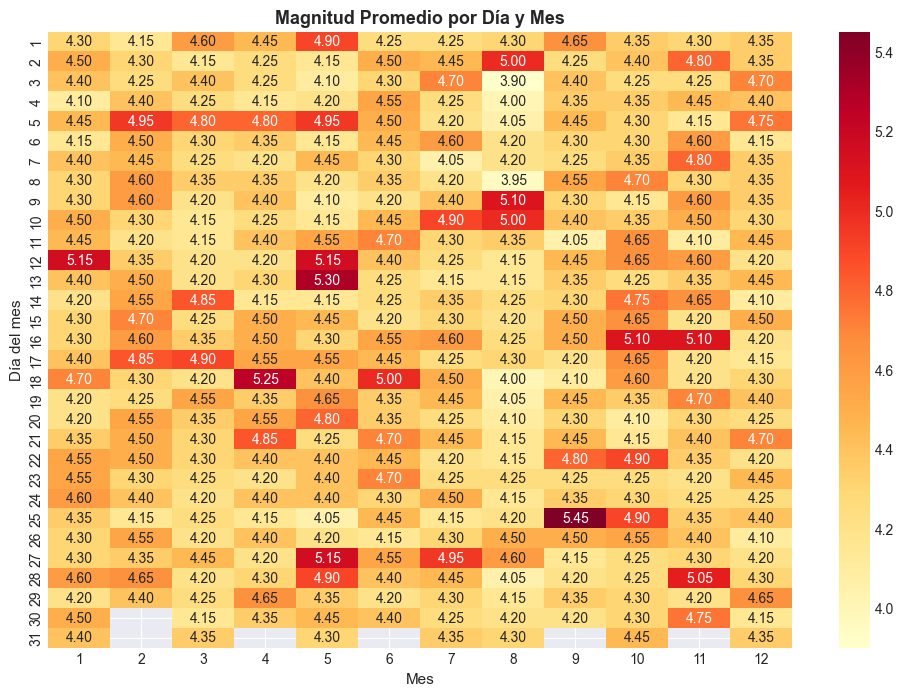

In [25]:
# Heatmap de magnitudes promedio por mes y día
pivot_magnitud = sismos_max_diarios.pivot_table(
    values='Magnitud',
    index=sismos_max_diarios['Fecha'].dt.day,
    columns=sismos_max_diarios['Fecha'].dt.month,
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_magnitud, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Día del mes', fontsize=11)
ax.set_title('Magnitud Promedio por Día y Mes', fontsize=13, fontweight='bold')
plt.show()